#  Lesson 3: Feed-Forward, Layer Norm & Residuals

### __The parts that make a Transformer actually trainable__

# The Problem First

Multi-head attention (Lesson 2) is fantastic at one thing: letting every token gather relevant information from every other token. But two practical problems remain if you just stack attention layers directly on top of each other:

__Problem 1__ — Attention barely "thinks." For a fixed set of attention weights, the output at each position is just a weighted linear combination of other tokens' value vectors. That's powerful for gathering the right information, but it doesn't give the model much room to nonlinearly process what it gathered. Stack ten linear operations and, mathematically, they can collapse toward something not much richer than one.

__Problem 2__ — Deep stacks don't train. GPT-3 has 96 layers. If you tried stacking 96 attention layers directly, training would fail almost immediately — the exact vanishing-gradient disease we diagnosed with RNNs back in Stage 2, Lesson 4, except now the gradient has to survive backpropagating through layers instead of through time.

This lesson fixes both. The feed-forward network gives every token real nonlinear processing power. LayerNorm + residual connections are what let you stack dozens or hundreds of layers and still train reliably.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class feedforward(nn.Module):
    def __init__(self,d_model,d_ff,dropout=0.1):
        super().__init__()
        self.Linear1=nn.Linear(d_model,d_ff)
        self.Linear2=nn.Linear(d_ff,d_model)
        self.dropout=nn.Dropout(dropout)

    def forward(self,x):
        x=self.Linear1(x)
        x=F.gelu(x)
        x=self.dropout(x)
        x=self.Linear2(x)
        return x

d_model,d_ff=512,2048
ffn=feedforward(d_model,d_ff)
x=torch.randn(2,10,d_model)
out=ffn(x)
print("Input: ", x.shape)
print("Output:", out.shape, "— same shape, every token individually transformed")




Input:  torch.Size([2, 10, 512])
Output: torch.Size([2, 10, 512]) — same shape, every token individually transformed


__Why expand to 4x and then contract back? Projecting into a higher-dimensional space gives the nonlinearity more "room" to carve out complex functions before compressing back down to d_model. 4x is what the original paper found worked well, and it stuck — though modern models use slightly different ratios (more on that below).__

# Part B : Layer Normalization 

Deep networks are fragile: as data flows through many layers, activation values can drift, balloon, or collapse, forcing you to use tiny learning rates just to avoid blowing up. LayerNorm re-centers and re-scales every token's vector at every layer, so the network sees a consistent, stable distribution no matter how deep it is.

In [2]:
class LayerNorm(nn.Module):
    def __init__(self,d_model,eps=1e-6):
        super().__init__()
        self.gamma=nn.Parameter(torch.ones(d_model))
        self.beta=nn.Parameter(torch.zeros(d_model))
        self.eps=eps

    def forward(self,x):
        mean=x.mean(dim=-1,keepdim=True)
        var=x.var(dim=-1,keepdim=True,unbiased=False)
        x_norm=(x-mean)/torch.sqrt(var+self.eps)
        return self.gamma*x_norm+self.beta
    
ln = LayerNorm(d_model=8)
x  = torch.randn(2, 5, 8) * 10 + 50    # deliberately huge, shifted values
out = ln(x)
print("Before — mean:", x.mean(dim=-1)[0,0].item(), " std:", x.std(dim=-1, unbiased=False)[0,0].item())
print("After  — mean:", out.mean(dim=-1)[0,0].item(), " std:", out.std(dim=-1,unbiased=False)[0,0].item())
print("\n→ Renormalized to mean≈0, std≈1 — no matter how large the raw values were.")

Before — mean: 59.00802230834961  std: 11.822846412658691
After  — mean: 3.3527612686157227e-08  std: 0.9999999403953552

→ Renormalized to mean≈0, std≈1 — no matter how large the raw values were.


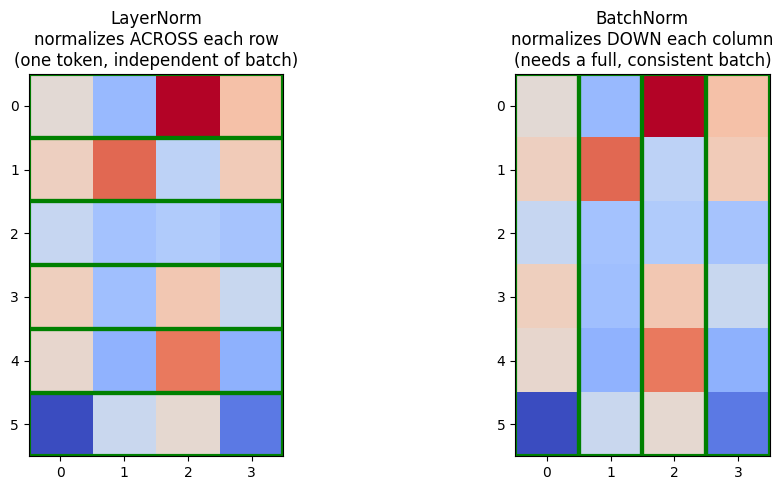

In [3]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(11,5))
data = np.random.randn(6, 4) * 3 + 5   # 6 tokens (rows) x 4 features (cols)

axes[0].imshow(data, cmap='coolwarm')
for i in range(6):
    axes[0].add_patch(plt.Rectangle((-.5, i-.5), 4, 1, fill=False, edgecolor='green', linewidth=3))
axes[0].set_title("LayerNorm\nnormalizes ACROSS each row\n(one token, independent of batch)")

axes[1].imshow(data, cmap='coolwarm')
for j in range(4):
    axes[1].add_patch(plt.Rectangle((j-.5, -.5), 1, 6, fill=False, edgecolor='green', linewidth=3))
axes[1].set_title("BatchNorm\nnormalizes DOWN each column\n(needs a full, consistent batch)")

plt.tight_layout()
plt.savefig("layernorm_vs_batchnorm.png", dpi=150)
plt.show()

1. What happens if we keep dim = 1 instead of dim = -1?

To see why dim = 1 breaks LayerNorm, let's look at the shape of your tensor: [Batch=2, Seq=5, Features=8]

| Dimension index | What it represents | example in our code |
| :-----: | :-----: | :-----: |
| dim=0 | Batch size | 2 different sentences |
| dim=1 | Sequence Length | 5 words in sentence |
| dim=-1 or 2 | Features/Embedding size | 8 Numerical features describing single word |

If you use dim = 1 (The Disaster):
You are telling PyTorch: "For feature #0, calculate the average across all 5 words in the sentence!"

Here is why this is catastrophic for a language model:

You destroy word individuality: You are mixing the grammar and meaning of "king" with "land". The features of word 1 get scaled based on what word 5 happens to be!

Padding Token Poisoning: In real batches, short sentences are padded with zero-tokens (<PAD>). If you average across dim = 1, all those zeros get factored into the mean, completely corrupting the math for the real words!

Why negative indexing (dim = -1)?
In Python, -1 always means "the very last dimension". Why use -1 instead of 2? Because during inference, you might pass a single un-batched sentence with shape [5, 8] (2 dimensions instead of 3). If you hardcoded dim = 2, your code would crash with an IndexError! Using dim = -1 ensures your code always normalizes the embedding features, regardless of how many outer batch dimensions exist.
___________________________________________________________________________________________________

2. Why keepdim = True? What happens if it is False?
This comes down to how PyTorch performs Tensor Broadcasting when you try to subtract the mean from your data: x - mean.

Let’s trace the exact tensor shapes for x = torch.randn(2, 5, 8):

Scenario A: keepdim = True (Why it works)
When you tell PyTorch to keep the dimension, it collapses the 8 numbers into 1 average, but it keeps the empty room as a placeholder of size 1:
* Shape of x: [2, 5, 8]
* Shape of mean: [2, 5, 1]
When you run x - mean, PyTorch aligns the shapes from right to left. It sees an 8 and a 1. Because one of them is a 1, PyTorch uses broadcasting: it automatically stretches that single average across all 8 columns in memory and subtracts cleanly!

Scenario B: keepdim = False (Why it crashes)

If you set keepdim = False (or leave it out, since False is PyTorch's default!), PyTorch completely destroys the last dimension:
* Shape of x: [2, 5, 8]
* Shape of mean: [2, 5] (Notice the 3rd dimension is gone!)

Now, when you try to run x - mean, PyTorch aligns the shapes from right to left:
* It tries to match the trailing dimension of x (8) with the trailing dimension of mean (5)
* Because $8 \neq 5$, PyTorch throws up its hands and crashes your program with a fatal error:RuntimeError: The size of tensor a (8) must match the size of tensor b (5) at non-singleton dimension 2
___________________________________________________________________________________________________

__Never use BatchNorm in a Transformer.__

# Part C — Residual Connections

__Recall the vanishing gradient problem from RNNs: gradients shrink toward zero as they backpropagate through many steps. The exact same disease hits deep stacks of layers.__

In [4]:
class DeepwithNoResidual(nn.Module):
    def __init__(self,d_model,depth):
        super().__init__()
        self.Layers=nn.ModuleList([nn.Linear(d_model,d_model)for _ in range (depth)])
    def forward(self,x):
        for layer in self.Layers:
            x=torch.tanh(layer(x))
        return x
        
class DeepWithResidual(nn.Module):
    def __init__(self,d_model,depth):
        super().__init__()
        self.Layers=nn.ModuleList([nn.Linear(d_model,d_model)for _ in range(depth)])
    def forward(self,x):
        for layer in self.Layers:
            x=x+torch.tanh(layer(x))
        return x
d_model,depth=32,30
x_input=torch.randn(1,d_model,requires_grad=True)

for name, Model in [("WITHOUT residual", DeepwithNoResidual),
                     ("WITH residual",    DeepWithResidual)]:
    torch.manual_seed(0)
    model = Model(d_model, depth)
    x = x_input.clone().detach().requires_grad_(True)
    loss = model(x).sum()
    loss.backward()
    print(f"{name:20s} | gradient norm at the input after {depth} layers: {x.grad.norm().item():.8f}")




WITHOUT residual     | gradient norm at the input after 30 layers: 0.00000015
WITH residual        | gradient norm at the input after 30 layers: 36.58735657


# 1.Post-LN (Original 2017 Transformer):
__return self.norm(x + self.dropout(sublayer(x)))__

Why Post-LN broke down:
* In Post-LN, the data merges back onto the superhighway (x + ...), but then immediately gets slammed into a LayerNorm tollbooth.
* Because LayerNorm re-scales numbers by dividing by their variance, it acts as a non-linear obstacle on the main highway.
* When you run backpropagation through 50 or 100 layers, the error signal has to fight through 50 to 100 of these normalization tollbooths.

The Result: The gradients would frequently explode or vanish during the first few minutes of training. To prevent the model from crashing, engineers had to use complicated "learning rate warm-up" tricks (starting with a tiny learning rate and slowly increasing it over thousands of steps).
______________________________________________________________________________________________

# 2. The Modern Way: Pre-LN (Your Code!)
Around 2019/2020, researchers realized that moving LayerNorm inside the branch solved the instability problem permanently:
### Pre-LN (Modern: GPT-3, GPT-4, LLaMA, Mistral - YOUR CODE):
__return x + self.dropout(sublayer(self.norm(x)))__

* Why Pre-LN dominates AI today:
Look at the superhighway now: x + ... is completely untouched!
* The normalization happens inside the local workshop, before the Attention or Feed-Forward math even begins.
* When backpropagation runs right-to-left, the error signal can fly down the x + superhighway from Layer 100 all the way to Layer 1 at 100% speed, without a single LayerNorm tollbooth blocking its path!

The Result: Modern LLMs train smoothly right out of the box. You don't need fragile learning rate warmups, and you can comfortably stack 80, 100, or 140+ layers without the training run collapsing.

Input shape:  torch.Size([1, 11, 64])
Output shape: torch.Size([1, 11, 64])
Weights shape (batch, heads, seq, seq): torch.Size([1, 4, 11, 11])


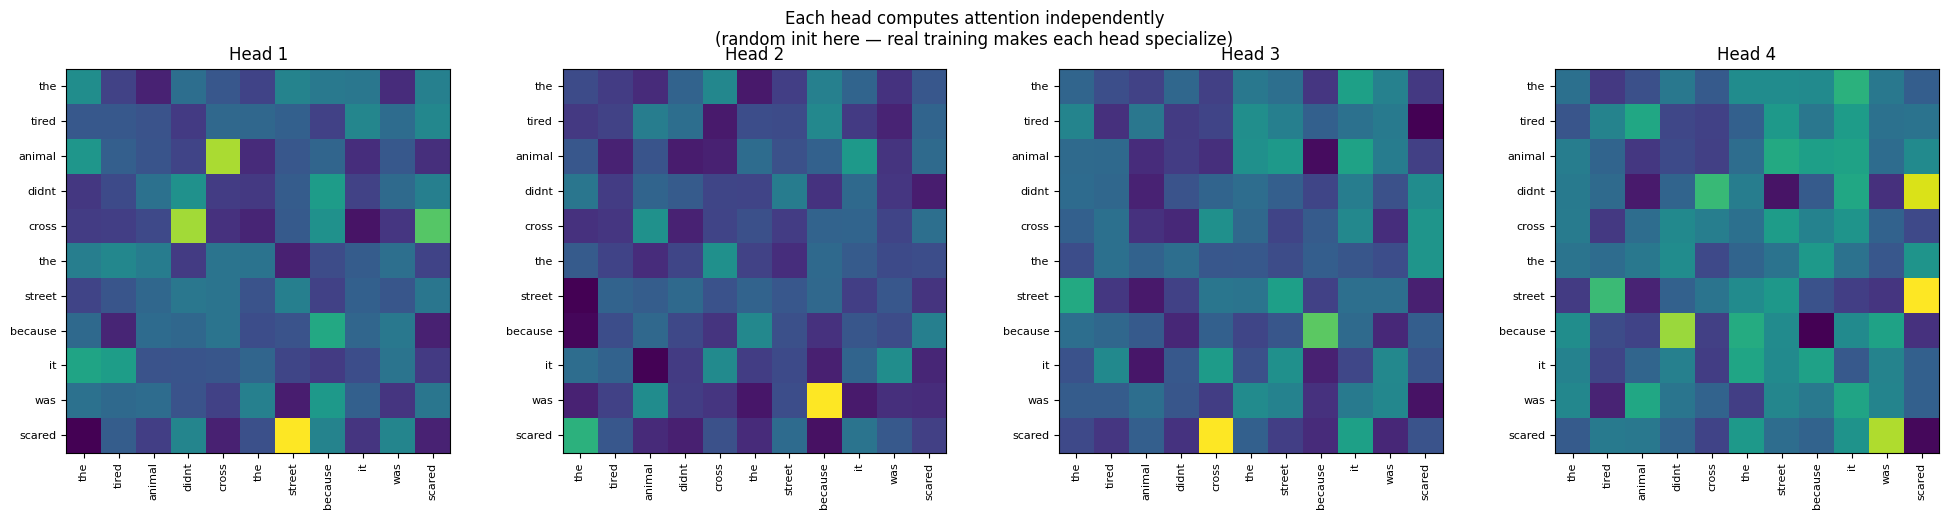

Params, 1 head:  16640
Params, 4 heads: 16640
Params, 8 heads: 16640

→ Identical parameter count. num_heads only changes HOW we
  reshape and split the same W_Q, W_K, W_V, W_O matrices —
  it doesn't add capacity, it restructures it into parallel views.


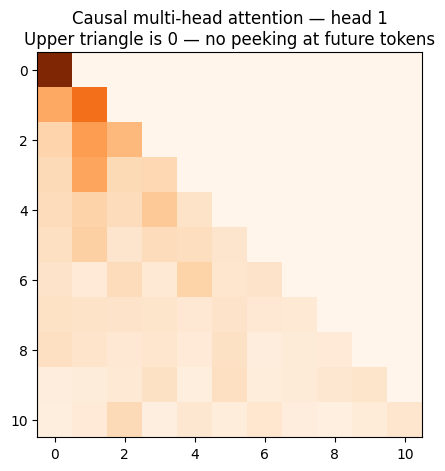

Output shape:  torch.Size([1, 11, 64])
Weights shape: torch.Size([1, 4, 11, 11])

Note: by default PyTorch AVERAGES weights across heads.
Pass average_attn_weights=False to inspect each head separately.


In [5]:
# 1. Load MultiHeadAttention from Notebook 02
%run 02_multihead_attention.ipynb



In [6]:

class SublayerConnection(nn.Module):
    """
    Wraps ANY sublayer (attention OR feed-forward) with:
      1. Layer norm — applied BEFORE the sublayer (Pre-LN)
      2. Residual — the ORIGINAL x added back after
    This is reused twice per Transformer block: once for attention,
    once for the FFN.
    """
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.norm    = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))


# --- Using it with our Lesson 2 MultiHeadAttention ---
d_model = 64
mha  = MultiHeadAttention(d_model, num_heads=4)
conn = SublayerConnection(d_model)

x = torch.randn(1, 10, d_model)
# lambda wraps MHA since it returns (output, weights) — we only want output
out = conn(x, lambda x: mha(x)[0])
print("Input: ", x.shape)
print("Output:", out.shape, "— norm + attention + residual, all in one call")

Input:  torch.Size([1, 10, 64])
Output: torch.Size([1, 10, 64]) — norm + attention + residual, all in one call


__Q: Why pair attention with a feed-forward layer instead of just stacking more attention?__

Attention gathers information via a linear combination of value vectors; it doesn't have much capacity to nonlinearly transform what it gathers. The FFN's nonlinearity gives each token real per-position processing depth that attention alone can't provide.

__Q: Where do most of a Transformer's parameters actually live?__

The FFN layers — roughly two-thirds of total parameters at the standard 4x expansion ratio. Attention gets the architectural spotlight; FFN does most of the parameter "heavy lifting."

__Q: Why LayerNorm instead of BatchNorm for Transformers?__

BatchNorm normalizes per-feature across the batch — it degrades with variable-length padded sequences and breaks at inference with small or single-example batches. LayerNorm normalizes per-token across its own features, completely independent of batch size, which fits sequence models naturally.

__Q: What problem do residual connections solve, and where have we seen it before?__

Vanishing gradients — identical in spirit to the RNN problem from Stage 2 Lesson 4, but now across layers instead of across time. The addition in x + f(x) gives gradients a direct path back to early layers regardless of how deep the network is.

__Q: What's the practical difference between Pre-LN and Post-LN?__

Pre-LN normalizes before the sublayer, keeping the skip path completely clean; Post-LN normalizes after the residual add, which subtly disrupts that clean gradient path. Pre-LN is what makes stable training of very deep (96+ layer) models practical, and it's the near-universal modern choice.
